In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (150, 4)
Labels shape: (150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train.shape , y_train.shape

((120, 4), (120,))

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(10,activation='relu' ),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(3,activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs = 50,
    batch_size = 8,
    validation_split=0.2
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.2917 - loss: 1.4810 - val_accuracy: 0.5000 - val_loss: 1.1835
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3125 - loss: 1.3796 - val_accuracy: 0.5000 - val_loss: 1.1257
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3229 - loss: 1.2860 - val_accuracy: 0.5000 - val_loss: 1.0769
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3333 - loss: 1.2111 - val_accuracy: 0.5000 - val_loss: 1.0329
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3333 - loss: 1.1421 - val_accuracy: 0.5000 - val_loss: 0.9940
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3438 - loss: 1.0786 - val_accuracy: 0.5000 - val_loss: 0.9568
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3542 - loss: 1.0238 - val_accuracy: 0.6667 - val_loss: 0.9207
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5938 - loss: 0.9723 - val_accuracy: 0.7500 - val

In [ ]:
history.history.items()

dict_items([('accuracy', [0.2916666567325592, 0.3125, 0.3229166567325592, 0.3333333432674408, 0.3333333432674408, 0.34375, 0.3541666567325592, 0.59375, 0.71875, 0.71875, 0.7291666865348816, 0.7395833134651184, 0.75, 0.75, 0.7708333134651184, 0.78125, 0.8020833134651184, 0.8020833134651184, 0.8020833134651184, 0.8125, 0.8125, 0.8333333134651184, 0.8333333134651184, 0.8541666865348816, 0.8645833134651184, 0.8854166865348816, 0.8854166865348816, 0.8854166865348816, 0.8854166865348816, 0.8958333134651184, 0.8958333134651184, 0.8958333134651184, 0.8958333134651184, 0.8958333134651184, 0.8958333134651184, 0.8958333134651184, 0.90625, 0.9166666865348816, 0.9166666865348816, 0.9270833134651184, 0.9270833134651184, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9479166865348816, 0.9479166865348816, 0.9479166865348816, 0.9479166865348816]), ('loss', [1.480958342552185, 1.3795753717422485, 1.2859710454940796, 1.2111302614212036, 1.1421183347702026, 1.0786265134811401, 1.0238381624221802, 0.97225880622

In [ ]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.9333 - loss: 0.2216


[0.22160841524600983, 0.9333333373069763]

In [ ]:
prediction = model.predict(X_test)
np.argmax(prediction , axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


array([1, 0, 2, 1, 2, 0, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

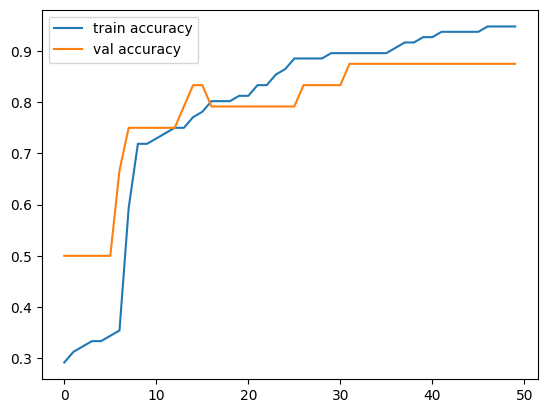

In [ ]:
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='val accuracy')
plt.legend()
plt.show()

In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')